<a href="https://colab.research.google.com/github/narsimha1603/Major-Project/blob/main/TSA_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.statespace.sarimax import SARIMAX

from mlxtend.frequent_patterns import apriori, association_rules
import warnings
# Suppress deprecation warnings from libraries
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [5]:
data = pd.read_csv(
    "dengue_dataset_5000_cases.csv",
    parse_dates=['Date']
).set_index('Date')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [8]:
# Resample to monthly frequency using 'ME' (Month End) instead of the deprecated 'M'
data = data.resample('ME').mean()

y = data['Dengue_Cases']

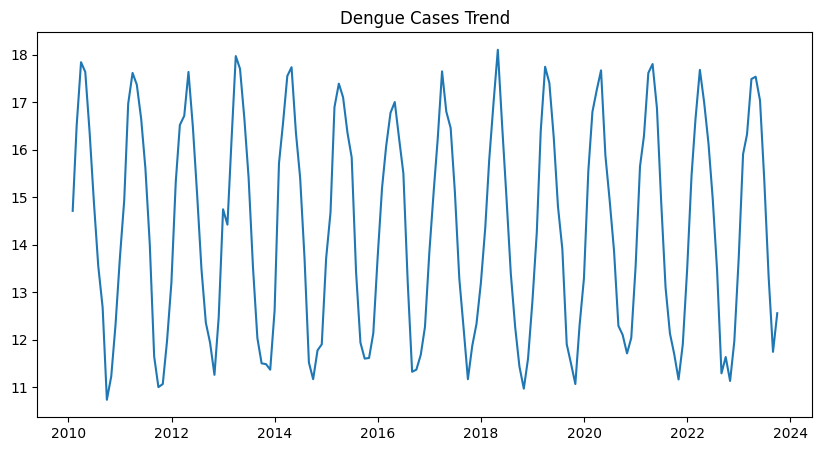

In [9]:
plt.figure(figsize=(10,5))
plt.plot(y)
plt.title("Dengue Cases Trend")
plt.show()

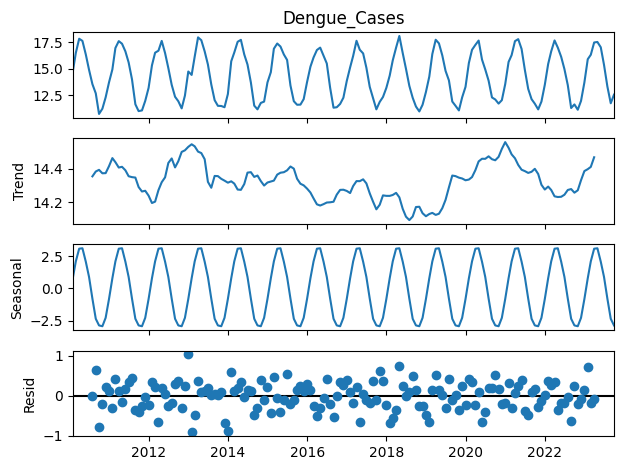

In [10]:
decomposition = seasonal_decompose(y, model='additive', period=12)

decomposition.plot()
plt.show()

In [12]:
# Fill missing values using the updated ffill() method
data = data.ffill()

# Normalize weather features
scaler = MinMaxScaler()

data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']] = scaler.fit_transform(
    data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']]
)

# Stationarity Test
result = adfuller(y)
print("ADF p-value:", result[1])

ADF p-value: 0.01341025551791118


In [13]:
arm_data = data.copy()

arm_data['High_Temp'] = arm_data['Temperature (°C)'] > arm_data['Temperature (°C)'].mean()
arm_data['High_Rain'] = arm_data['Rainfall (mm)'] > arm_data['Rainfall (mm)'].mean()
arm_data['High_Humidity'] = arm_data['Humidity (%)'] > arm_data['Humidity (%)'].mean()
arm_data['High_Cases'] = arm_data['Dengue_Cases'] > arm_data['Dengue_Cases'].mean()

arm_df = arm_data[['High_Temp','High_Rain','High_Humidity','High_Cases']]

frequent = apriori(arm_df, min_support=0.3, use_colnames=True)

rules = association_rules(frequent, metric="confidence", min_threshold=0.6)

print("\nAssociation Rules")
print(rules[['antecedents','consequents','support','confidence']])


Association Rules
                               antecedents  \
0                              (High_Temp)   
1                              (High_Rain)   
2                              (High_Temp)   
3                          (High_Humidity)   
4                              (High_Temp)   
5                             (High_Cases)   
6                          (High_Humidity)   
7                              (High_Rain)   
8                              (High_Rain)   
9                             (High_Cases)   
10                         (High_Humidity)   
11                            (High_Cases)   
12              (High_Temp, High_Humidity)   
13                  (High_Temp, High_Rain)   
14              (High_Humidity, High_Rain)   
15                             (High_Temp)   
16                         (High_Humidity)   
17                             (High_Rain)   
18                  (High_Temp, High_Rain)   
19                 (High_Temp, High_Cases)   
20             

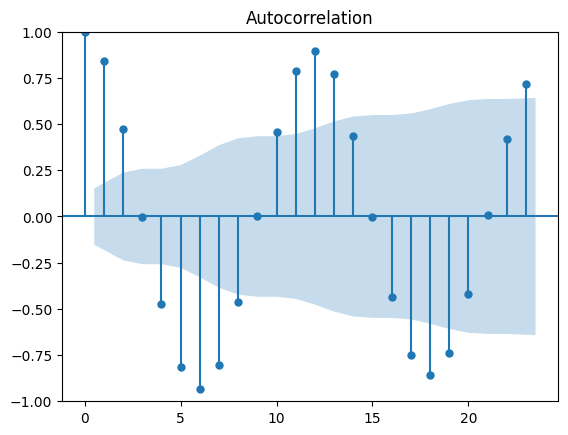

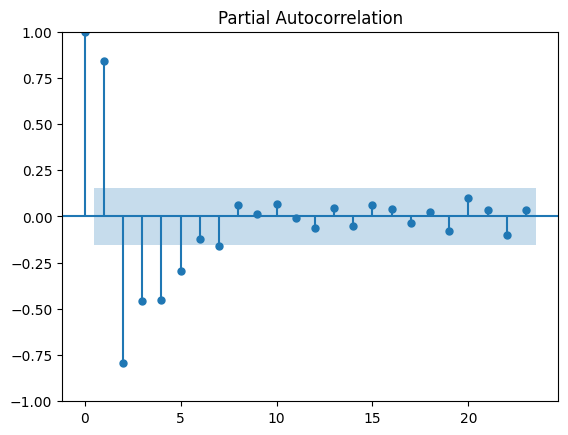

In [14]:
plot_acf(y)
plt.show()

plot_pacf(y)
plt.show()

In [15]:
# use recent data for faster training
y_train = y.tail(5000)

model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

model_fit = model.fit(disp=False)

print("SARIMA Model Ready")

SARIMA Model Ready


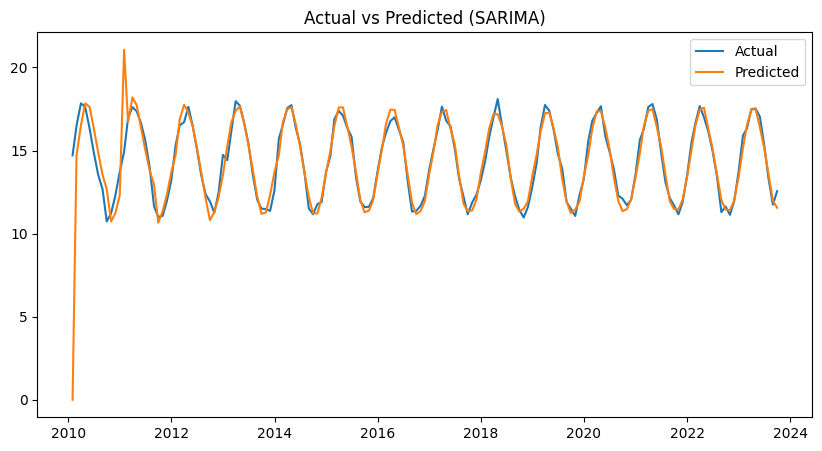

In [16]:
predicted = model_fit.predict(
    start=y_train.index[0],
    end=y_train.index[-1]
)

plt.figure(figsize=(10,5))
plt.plot(y_train, label="Actual")
plt.plot(predicted, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (SARIMA)")
plt.show()

In [17]:
rmse = np.sqrt(mean_squared_error(y_train, predicted))
mae = mean_absolute_error(y_train, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.3534756385953262
MAE: 0.5324736742660701


In [19]:
last_date = y.index[-1]
end_date = pd.Timestamp("2027-12-31")

steps = (end_date.year - last_date.year) * 12 + (end_date.month - last_date.month)

forecast = model_fit.forecast(steps=steps)

# Updated freq to 'ME' to avoid FutureWarning
future_dates = pd.date_range(start=last_date, periods=steps+1, freq='ME')[1:]

forecast_series = pd.Series(forecast.values, index=future_dates)

print("\nForecast (2026–2027)")
print(forecast_series)


Forecast (2026–2027)
2023-10-31    11.523064
2023-11-30    12.089760
2023-12-31    13.508987
2024-01-31    15.274957
2024-02-29    16.479665
2024-03-31    17.529334
2024-04-30    17.495663
2024-05-31    16.467025
2024-06-30    15.143141
2024-07-31    13.528847
2024-08-31    11.936722
2024-09-30    11.721836
2024-10-31    11.402193
2024-11-30    12.076241
2024-12-31    13.540194
2025-01-31    15.354168
2025-02-28    16.472711
2025-03-31    17.534768
2025-04-30    17.510221
2025-05-31    16.539466
2025-06-30    15.178091
2025-07-31    13.516640
2025-08-31    11.925775
2025-09-30    11.823736
2025-10-31    11.425879
2025-11-30    12.088149
2025-12-31    13.547195
2026-01-31    15.355902
2026-02-28    16.483899
2026-03-31    17.544596
2026-04-30    17.519048
2026-05-31    16.541943
2026-06-30    15.184681
2026-07-31    13.528404
2026-08-31    11.937401
2026-09-30    11.822980
2026-10-31    11.433705
2026-11-30    12.097267
2026-12-31    13.556851
2027-01-31    15.366136
2027-02-28    16.4

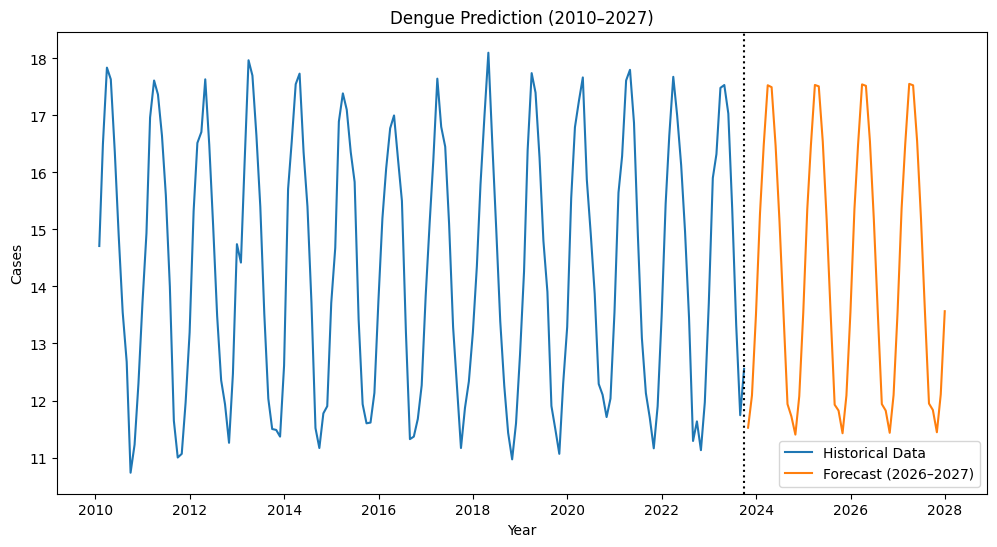

In [20]:
plt.figure(figsize=(12,6))

plt.plot(y, label="Historical Data")
plt.plot(forecast_series, label="Forecast (2026–2027)")

plt.axvline(x=last_date, color='black', linestyle=':')

plt.title("Dengue Prediction (2010–2027)")
plt.xlabel("Year")
plt.ylabel("Cases")

plt.legend()
plt.show()

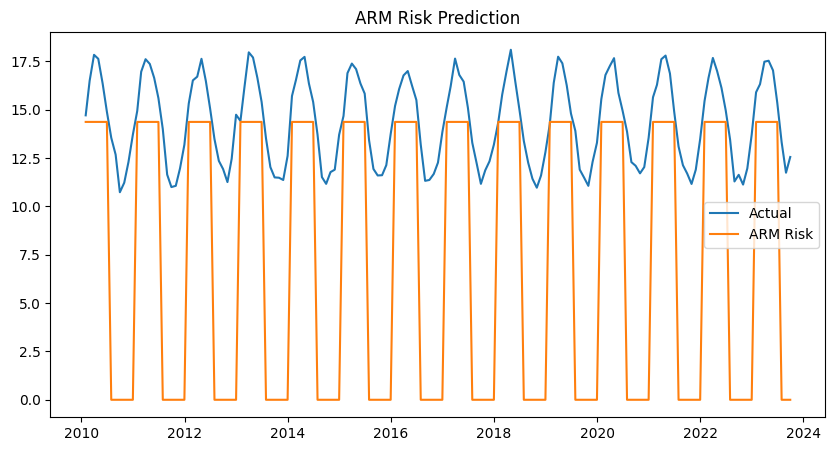

In [21]:
risk_prediction = arm_data['High_Temp'] & arm_data['High_Rain'] & arm_data['High_Humidity']

risk_prediction = risk_prediction.astype(int)

plt.figure(figsize=(10,5))

plt.plot(data.index, data['Dengue_Cases'], label="Actual")
plt.plot(data.index, risk_prediction * data['Dengue_Cases'].mean(), label="ARM Risk")

plt.legend()
plt.title("ARM Risk Prediction")

plt.show()